# CIFAR-10 对比实验（ViT-Base vs D2NN-12，使用相同全连接头）

> 这个 Notebook 适用于云端 Jupyter / Colab / 其他 notebook 运行环境。  
> 目标：
> 1. 跑 **ViT-Base** 在 CIFAR-10 上的分类性能  
> 2. 跑 **D2NN 12层衍射 + 同一全连接头** 在 CIFAR-10 上的性能  
> 3. 给出可视化：样本展示、训练曲线、混淆矩阵、预测样例

By 陈云海 2026.02.16 04:40

重新检查并小幅修改于 2026.03.04 主要是再次检查分析了当前任务的完成情况；增加了更多的训练EPOCH，使得两种模式均能训练至基本收敛；补充了一些思路上的注释、与可思考与改进的点。

## 0) 检验是否内存足够

In [3]:
import subprocess
print(subprocess.check_output(
    ["nvidia-smi","--query-gpu=memory.total,memory.used,memory.free","--format=csv,noheader"],
    text=True
))

12288 MiB, 3 MiB, 11908 MiB



## 1) 导入依赖 + 基础配置

- 这部分只做：导入包、设置随机种子、检查设备（GPU/CPU）。

In [ ]:
import os
import random
import math
import json
from dataclasses import dataclass, asdict
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.models import vit_b_16
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# -------------------------
# 基础配置（可按需修改）
# -------------------------
SEED = 42
BATCH_SIZE = 64
EPOCHS = 50
LR = 1e-4
NUM_WORKERS = 2
DATA_DIR = Path("./data")
OUT_DIR = Path("./results")
OUT_DIR.mkdir(parents=True, exist_ok=True)

PREFERRED_DEVICE = "cuda"  # 可改为 "cpu" 或 "cuda"


def set_seed(seed: int = 42):
    """设置随机种子，保证结果尽可能可复现。"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def resolve_device(preferred: str = "cuda") -> torch.device:
    """选择训练设备：优先用用户指定设备，不可用则自动回退。"""
    if preferred.startswith("cuda") and not torch.cuda.is_available():
        print("⚠️ 检测到你请求 CUDA，但当前云环境无可用 GPU，自动回退到 CPU。")
        return torch.device("cpu")
    dev = torch.device(preferred)
    print(f"✅ 当前使用设备: {dev}")
    return dev


set_seed(SEED)
DEVICE = resolve_device(PREFERRED_DEVICE)
print("✅ 基础配置完成")

✅ 当前使用设备: cuda
✅ 基础配置完成


## 2) 数据加载（CIFAR-10）+ 可视化检查

- 这里会下载/读取 CIFAR-10，并创建 train/test loader。
- 会展示一小批图片，确认数据和标签正常。

我在这部分完成了 CIFAR-10 数据的加载与预处理。关键点包括：将 32x32 图像 resize 到 224x224 以匹配 ViT 输入；训练集加入随机水平翻转增强泛化能力；使用 mean=0.5, std=0.5 进行标准化；并根据设备类型动态启用 pin_memory 加速数据传输。同时，我设置了合理的 batch_size=64 和 num_workers=2，并关闭了测试集的 shuffle 以保证评估一致性。最后，打印了数据量和类别名称，确认加载无误。

In [5]:
# 为了和 ViT 输入对齐，这里把 CIFAR-10 的 32x32 resize 到 224x224
train_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

test_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

train_ds = datasets.CIFAR10(root=str(DATA_DIR), train=True, download=False, transform=train_tfms)
test_ds = datasets.CIFAR10(root=str(DATA_DIR), train=False, download=False, transform=test_tfms)
classes = train_ds.classes

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
)

print(f"✅ 数据加载完成: train={len(train_ds)}, test={len(test_ds)}")
print(f"✅ 类别: {classes}")

✅ 数据加载完成: train=50000, test=10000
✅ 类别: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


/tmp/ipykernel_5803/3619643007.py:19: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5803/3619643007.py:19: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5803/3619643007.py:19: UserWarning: Glyph 21487 (\N{CJK UNIFIED IDEOGRAPH-53EF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5803/3619643007.py:19: UserWarning: Glyph 35270 (\N{CJK UNIFIED IDEOGRAPH-89C6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5803/3619643007.py:19: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5803/3619643007.py:19: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5803/3619643007.py:19: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}

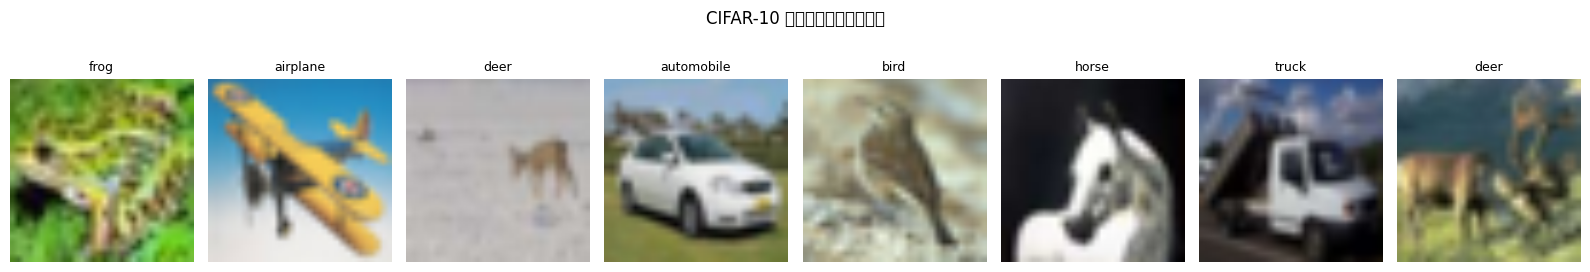

✅ 样本展示完成


In [6]:
# 展示一批样本（只在 CPU 做，不占 GPU）
def denorm(x):
    return x * 0.5 + 0.5

imgs, labels = next(iter(train_loader))
imgs = imgs.cpu()
labels = labels.cpu()

show_n = min(8, imgs.size(0))
plt.figure(figsize=(16, 3))
for i in range(show_n):
    ax = plt.subplot(1, show_n, i + 1)
    img = denorm(imgs[i]).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.set_title(classes[int(labels[i])], fontsize=9)
    ax.axis("off")
plt.suptitle("CIFAR-10 样本可视化（训练集）", fontsize=12)
plt.tight_layout()
plt.show()
print("✅ 样本展示完成")


## 3) 模型定义（共享全连接头）

> 这里沿用仓库 D2NN 思路：复数场 + 可学习相位层 + 层间传播。  
> 对比公平性：两个模型都接入同一种全连接分类头（SharedFCHead）。
>
> 在这部分定义了三个核心组件：首先是共享分类头 SharedFCHead，确保 ViT 和 D2NN 使用相同的分类器，保障对比公平性；其次是 ViTWithSharedHead，它加载预训练的 ViT-Base 并替换其原始头为我们自定义的头；最后是 DiffractiveLayer，实现了 D2NN 的核心物理机制——通过可学习相位调制复数光场。特别地，我在 DiffractiveLayer 中使用 sigmoid * 2π 约束相位范围，并用 exp(1j * phase) 实现复数域旋转，完全遵循光学原理。

In [7]:
class SharedFCHead(nn.Module): # 共享全连接头
    # 共享分类头：Linear -> ReLU -> Dropout -> Linear
    def __init__(self, in_dim: int, hidden_dim: int = 512, num_classes: int = 10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),  # 768(ViT)/8*8(D2NN) -> 512
            nn.ReLU(inplace=True),  # 激活函数 ReLU 引入非线性
            nn.Dropout(0.1), # Dropout设置为10%，根据拟合准确度可以选择增加或降低
            nn.Linear(hidden_dim, num_classes),  # 512 -> 10
        ) 
        # 这么写共享分类头“公平”但并不“公正”。这里只是为了让两种方式的全连接头一致。
        # 事实上可以考虑换成根据两种方法自己的原始维数与特点制定各自的分类头分别提取特征，比如保留ViT的原始分类头架构、并给 D2NN 引入轻量级 CNN 头，双方均会有更好的结果。
    def forward(self, x):
        return self.net(x)


class ViTWithSharedHead(nn.Module):
    """ViT-Base 主干 + 共享全连接头"""
    def __init__(self, num_classes: int = 10, fc_hidden_dim: int = 512):
        super().__init__()
        self.backbone = vit_b_16(weights=None)
        in_dim = self.backbone.heads.head.in_features
        self.backbone.heads = nn.Identity()  # 去掉原始分类头
        self.head = SharedFCHead(in_dim, hidden_dim=fc_hidden_dim, num_classes=num_classes)

    def forward(self, x):
        feat = self.backbone(x)
        return self.head(feat)

# D2NN 模型（不用DNN类了）
class DiffractiveLayer(nn.Module):
    def __init__(self, channels: int, height: int, width: int):
        super().__init__()
        # raw 参数映射到 [0, 2pi]
        self.phase_raw = nn.Parameter(torch.zeros(channels, height, width))

    def forward(self, field: torch.Tensor) -> torch.Tensor:
        phase = 2 * torch.pi * torch.sigmoid(self.phase_raw)
        return field * torch.exp(1j * phase)


class D2NN12WithSharedHead(nn.Module):
    def __init__(self, img_size: int = 224, channels: int = 3, num_classes: int = 10, fc_hidden_dim: int = 512):
        super().__init__()
        self.layers = nn.ModuleList([DiffractiveLayer(channels, img_size, img_size) for _ in range(12)])

        # ASM 传播核（贴近仓库逻辑）
        wl = 532e-9
        pixel_size = 8e-6
        distance = 0.01
        fx = np.fft.fftshift(np.fft.fftfreq(img_size, d=pixel_size))
        fy = np.fft.fftshift(np.fft.fftfreq(img_size, d=pixel_size))
        fxx, fyy = np.meshgrid(fx, fy)
        inside = (1.0 / wl) ** 2 - fxx ** 2 - fyy ** 2
        inside[inside < 0] = 0
        kz = 2 * np.pi * np.sqrt(inside)
        h = np.exp(1j * kz * distance).astype(np.complex64)
        self.register_buffer("transfer", torch.from_numpy(h))

        self.pool = nn.AdaptiveAvgPool2d((8, 8))
        self.fc_head = SharedFCHead(channels * 8 * 8, hidden_dim=fc_hidden_dim, num_classes=num_classes)

    def propagate(self, field: torch.Tensor) -> torch.Tensor:
        spec = torch.fft.fftshift(torch.fft.fft2(field), dim=(-2, -1))
        out_spec = spec * self.transfer
        return torch.fft.ifft2(torch.fft.ifftshift(out_spec, dim=(-2, -1)))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        field = x.to(torch.complex64)
        for layer in self.layers:
            field = layer(field)
            field = self.propagate(field)
        intensity = torch.abs(field) ** 2
        pooled = self.pool(intensity).flatten(1)
        return self.fc_head(pooled)



print("✅ 模型定义完成")

✅ 模型定义完成


In [8]:
# D2NN 两阶段参数冻结策略： 用于分阶段训练不同参数，达到更好训练效果
def select_phase_only_params(model: nn.Module):
    
    # 第一阶段：训练 phase + fc_head（因为只训练 phase 在 CIFAR10 往往卡在接近随机水平）
    for p in model.parameters():
        p.requires_grad = False
    params_to_update = []
    for name, p in model.named_parameters():
        if ("phase_raw" in name) or ("fc_head" in name):
            p.requires_grad = True
            params_to_update.append(p)
    return params_to_update


def unfreeze_all_params(model: nn.Module):
    # 第二阶段：解锁全参数微调
    for p in model.parameters():
        p.requires_grad = True
    return [p for p in model.parameters() if p.requires_grad]



## 4) 训练与评估工具（带进度条 + 训练日志）

- 每个 epoch 都有 tqdm 进度条
- 会记录训练损失、测试准确率，后面可画曲线

In [9]:
@dataclass
class RunMetrics:
    model: str
    epochs: int
    best_val_acc: float
    last_val_acc: float
    last_train_loss: float


def evaluate(model, loader, device):
    model.eval()
    total, correct = 0, 0
    preds_all, labels_all = [], []

    with torch.no_grad():
        for x, y in tqdm(loader, desc="Eval", leave=False):
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            logits = model(x)
            preds = logits.argmax(dim=1)

            total += y.size(0)
            correct += (preds == y).sum().item()
            preds_all.append(preds.cpu())
            labels_all.append(y.cpu())

    acc = correct / max(total, 1)
    preds_all = torch.cat(preds_all) if preds_all else torch.tensor([])
    labels_all = torch.cat(labels_all) if labels_all else torch.tensor([])
    return acc, preds_all, labels_all


def train_model(model, train_loader, test_loader, device, epochs=5, lr=1e-4):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    history = {"train_loss": [], "val_acc": []}
    best_acc = 0.0
    final_preds, final_labels = None, None

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss, total_samples = 0.0, 0

        pbar = tqdm(train_loader, desc=f"Train Epoch {epoch}/{epochs}")
        for x, y in pbar:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            bs = y.size(0)
            running_loss += loss.item() * bs
            total_samples += bs
            pbar.set_postfix(loss=f"{loss.item():.4f}")

        epoch_loss = running_loss / max(total_samples, 1)
        val_acc, preds, labels = evaluate(model, test_loader, device)

        history["train_loss"].append(epoch_loss)
        history["val_acc"].append(val_acc)

        if val_acc >= best_acc:
            best_acc = val_acc
            final_preds, final_labels = preds, labels

        print(f"✅ Epoch {epoch}: train_loss={epoch_loss:.4f}, val_acc={val_acc*100:.2f}%")

    metrics = RunMetrics(
        model=model.__class__.__name__,
        epochs=epochs,
        best_val_acc=best_acc,
        last_val_acc=history["val_acc"][-1],
        last_train_loss=history["train_loss"][-1],
    )
    return metrics, history, final_preds, final_labels


print("✅ 训练工具准备完成")

✅ 训练工具准备完成


In [ ]:
# D2NN 两阶段训练
import math
import torch
import torch.nn as nn

def train_d2nn_two_stage(model: nn.Module,
                         train_loader,
                         val_loader,
                         device,
                         phase_epochs: int = 12,
                         finetune_epochs: int = 40,
                         phase_lr: float = 2e-3,
                         finetune_lr: float = 3e-4):

    # -------------------------
    # Stage-1: freeze -> train_model
    # -------------------------
    print("\n[Stage-1] 只训练 phase(+fc_head)")
    for p in model.parameters():
        p.requires_grad_(False)


    for name, p in model.named_parameters():
        if ("phase" in name) or ("fc_head" in name):
            p.requires_grad_(True)


    s1_metrics, s1_hist, s1_preds, s1_labels = train_model(
        model, train_loader, val_loader, device, epochs=phase_epochs, lr=phase_lr
    )

    # -------------------------
    # Stage-2: unfreeze -> train_model
    # -------------------------
    print("\n[Stage-2] 解锁全参数联合微调")
    for p in model.parameters():
        p.requires_grad_(True)

    s2_metrics, s2_hist, s2_preds, s2_labels = train_model(
        model, train_loader, val_loader, device, epochs=finetune_epochs, lr=finetune_lr
    )

    # -------------------------
    # Merge history (保持 train_model 的字段)
    # -------------------------
    history = {
        "train_loss": s1_hist["train_loss"] + s2_hist["train_loss"],
        "val_acc": s1_hist["val_acc"] + s2_hist["val_acc"],
    }
    # 标记每个 epoch 属于哪个 stage
    history["stage"] = (["S1"] * len(s1_hist["val_acc"])) + (["S2"] * len(s2_hist["val_acc"]))

    # -------------------------
    # Choose best preds/labels across both stages
    # -------------------------
    s1_best = float(s1_metrics.best_val_acc)
    s2_best = float(s2_metrics.best_val_acc)

    if s2_best >= s1_best:
        best_acc = s2_best
        final_preds, final_labels = s2_preds, s2_labels
    else:
        best_acc = s1_best
        final_preds, final_labels = s1_preds, s1_labels

    # -------------------------
    # Build final RunMetrics (同 train_model)
    # -------------------------
    # epochs 总数
    total_epochs = phase_epochs + finetune_epochs
    last_val_acc = history["val_acc"][-1] if history["val_acc"] else 0.0
    last_train_loss = history["train_loss"][-1] if history["train_loss"] else math.nan

    metrics = RunMetrics(
        model=model.__class__.__name__,
        epochs=total_epochs,
        best_val_acc=best_acc,
        last_val_acc=last_val_acc,
        last_train_loss=last_train_loss,
    )

    return metrics, history, final_preds, final_labels

print("D2NN prepared")

D2NN prepared


## 5) 运行实验：ViT-Base + Shared FC

In [11]:
# ViT：
# 第一遍跑的时候将EPOCHS设定为5，正确率约为58%（因为看起来收敛了、而且ViT比较费时间），事实上可能并未完全收敛；将EPOCHS改为10后的结果如下。
# 如果有必要也可改成跑20/30/50等更多的轮次，但是似乎提升空间也不是很大，在我目前代码版本的该分类头与其他的训练写法下确实上限有限。
vit_model = ViTWithSharedHead(num_classes=10, fc_hidden_dim=512)
vit_metrics, vit_hist, vit_preds, vit_labels = train_model(
    vit_model, train_loader, test_loader, DEVICE, epochs=50, lr=LR
)
print("✅ ViT 实验结束")
print(vit_metrics)

Train Epoch 1/50: 100%|██████████| 782/782 [06:09<00:00,  2.12it/s, loss=1.4795]
                                                       

✅ Epoch 1: train_loss=1.7096, val_acc=41.85%


Train Epoch 2/50: 100%|██████████| 782/782 [06:10<00:00,  2.11it/s, loss=1.1896]
                                                       

✅ Epoch 2: train_loss=1.4087, val_acc=51.12%


Train Epoch 3/50: 100%|██████████| 782/782 [06:10<00:00,  2.11it/s, loss=1.2836]
                                                       

✅ Epoch 3: train_loss=1.2696, val_acc=54.93%


Train Epoch 4/50: 100%|██████████| 782/782 [06:10<00:00,  2.11it/s, loss=0.9841]
                                                       

✅ Epoch 4: train_loss=1.1735, val_acc=58.07%


IOPub message rate exceeded.     | 320/782 [02:32<03:39,  2.11it/s, loss=1.1450]
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



## 6) 运行实验：D2NN-12 + Shared FC

In [12]:
# D2NN：
# 新版本设置了第一轮 epoch 为 20 ，第二轮微调 epoch 为 30， 目前已经基本收敛。
d2nn_model = D2NN12WithSharedHead(img_size=224, channels=3, num_classes=10, fc_hidden_dim=512)

d2nn_metrics, d2nn_hist, d2nn_preds, d2nn_labels = train_d2nn_two_stage(d2nn_model,
                         train_loader,
                         test_loader,
                         DEVICE,
                         phase_epochs= 20,
                         finetune_epochs= 30,
                         phase_lr = 2e-3,
                         finetune_lr = 3e-4 )

print("D2NN metrics:", d2nn_metrics)

print("✅ D2NN 实验结束")
print(d2nn_metrics)


[Stage-1] 只训练 phase(+fc_head)


Train Epoch 1/20: 100%|██████████| 782/782 [00:52<00:00, 14.92it/s, loss=1.5024]
                                                       

✅ Epoch 1: train_loss=1.8484, val_acc=42.49%


Train Epoch 2/20: 100%|██████████| 782/782 [00:51<00:00, 15.27it/s, loss=1.4090]
                                                       

✅ Epoch 2: train_loss=1.5724, val_acc=46.35%


IOPub message rate exceeded.     | 325/782 [00:21<00:29, 15.40it/s, loss=1.6732]
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



## 7) 对比结果保存（JSON）

In [13]:
summary = {
    "vit_base_shared_fc": asdict(vit_metrics),
    "d2nn_12_shared_fc": asdict(d2nn_metrics),
}

out_file = OUT_DIR / "cifar10_vit_vs_d2nn_notebook.json"
out_file.write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding="utf-8")
print("✅ 对比结果已保存:", out_file) # 结果数据保存在这个创建的json文件中。如有必要，也可记录最优结果.pth文件，不过目前这个版本还没有这样去记录。
print(json.dumps(summary, indent=2, ensure_ascii=False))

✅ 对比结果已保存: results/cifar10_vit_vs_d2nn_notebook.json
{
  "vit_base_shared_fc": {
    "model": "ViTWithSharedHead",
    "epochs": 50,
    "best_val_acc": 0.7221,
    "last_val_acc": 0.7084,
    "last_train_loss": 0.08784616097629071
  },
  "d2nn_12_shared_fc": {
    "model": "D2NN12WithSharedHead",
    "epochs": 50,
    "best_val_acc": 0.5953,
    "last_val_acc": 0.5901,
    "last_train_loss": 0.7337496054458618
  }
}


## 8) 可视化：训练曲线（loss / acc）

/tmp/ipykernel_5803/4252150889.py:21: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5803/4252150889.py:21: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5803/4252150889.py:21: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5803/4252150889.py:21: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5803/4252150889.py:21: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5803/4252150889.py:21: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5803/4252150889.py:21: UserWarning: Glyph 39564 (\N{CJK UNIFIED IDEOGRAPH-9A8C}

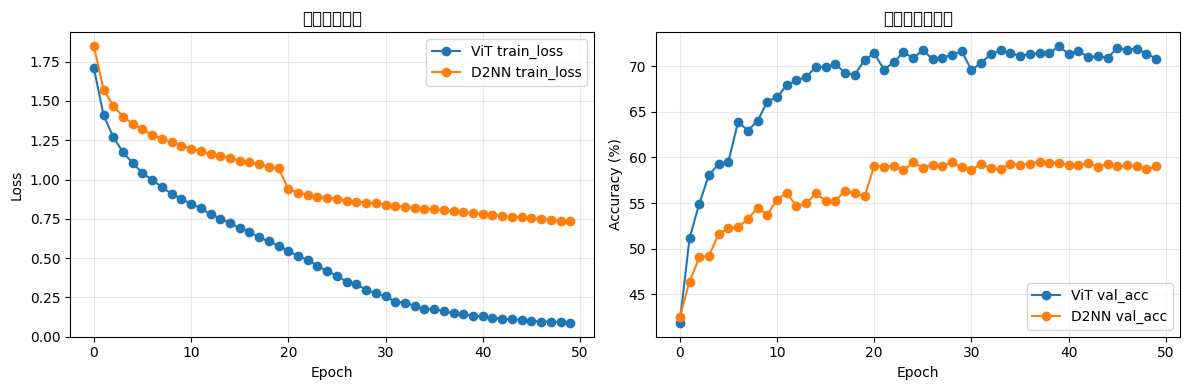

✅ 训练曲线绘制完成


In [14]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(vit_hist["train_loss"], marker="o", label="ViT train_loss")
plt.plot(d2nn_hist["train_loss"], marker="o", label="D2NN train_loss")
plt.title("训练损失曲线")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(np.array(vit_hist["val_acc"]) * 100, marker="o", label="ViT val_acc")
plt.plot(np.array(d2nn_hist["val_acc"]) * 100, marker="o", label="D2NN val_acc")
plt.title("验证准确率曲线")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()
print("✅ 训练曲线绘制完成")

## 9) 可视化：混淆矩阵

/tmp/ipykernel_5803/2137589014.py:28: UserWarning: Glyph 28151 (\N{CJK UNIFIED IDEOGRAPH-6DF7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5803/2137589014.py:28: UserWarning: Glyph 28102 (\N{CJK UNIFIED IDEOGRAPH-6DC6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5803/2137589014.py:28: UserWarning: Glyph 30697 (\N{CJK UNIFIED IDEOGRAPH-77E9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5803/2137589014.py:28: UserWarning: Glyph 38453 (\N{CJK UNIFIED IDEOGRAPH-9635}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/miniconda3/envs/py312/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 28151 (\N{CJK UNIFIED IDEOGRAPH-6DF7}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/miniconda3/envs/py312/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 28102 (\N{CJK UNIFIED IDEOGRAPH-6DC6}) missing from fon

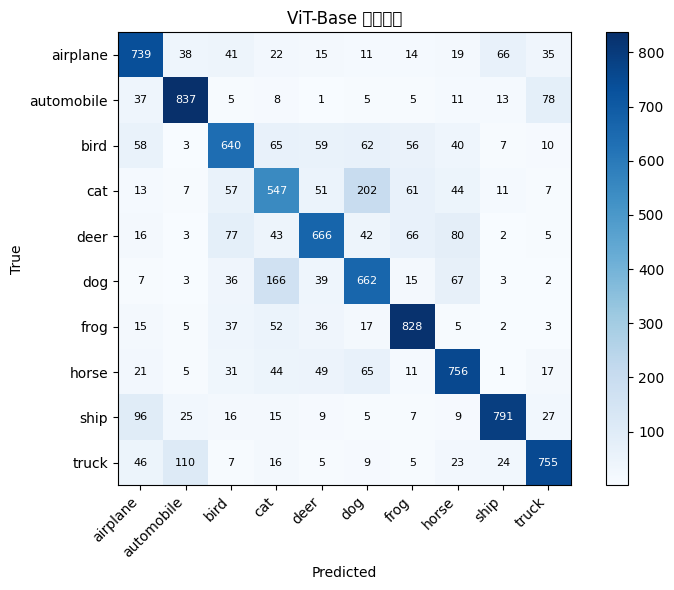

/tmp/ipykernel_5803/2137589014.py:28: UserWarning: Glyph 28151 (\N{CJK UNIFIED IDEOGRAPH-6DF7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5803/2137589014.py:28: UserWarning: Glyph 28102 (\N{CJK UNIFIED IDEOGRAPH-6DC6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5803/2137589014.py:28: UserWarning: Glyph 30697 (\N{CJK UNIFIED IDEOGRAPH-77E9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5803/2137589014.py:28: UserWarning: Glyph 38453 (\N{CJK UNIFIED IDEOGRAPH-9635}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/miniconda3/envs/py312/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 28151 (\N{CJK UNIFIED IDEOGRAPH-6DF7}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/miniconda3/envs/py312/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 28102 (\N{CJK UNIFIED IDEOGRAPH-6DC6}) missing from fon

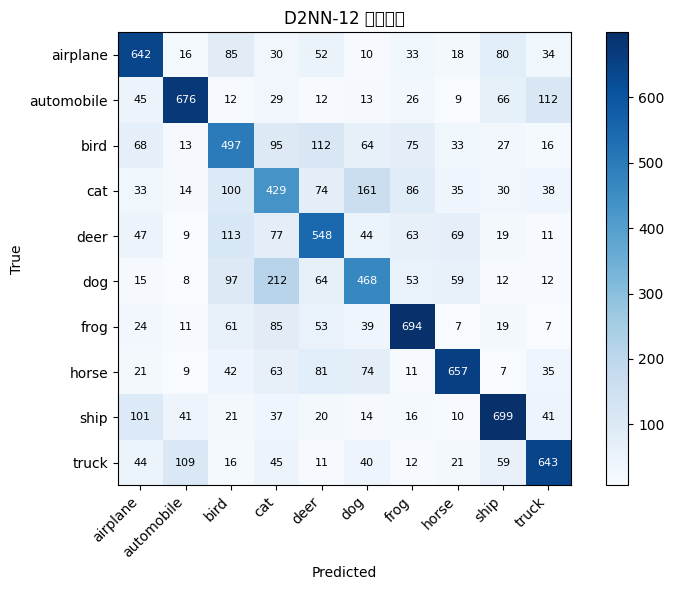

✅ 混淆矩阵绘制完成


In [15]:
def build_confusion_matrix(preds: torch.Tensor, labels: torch.Tensor, num_classes: int = 10):
    cm = torch.zeros((num_classes, num_classes), dtype=torch.int64)
    for p, t in zip(preds, labels):
        cm[t.long(), p.long()] += 1
    return cm


def plot_confusion_matrix(cm: torch.Tensor, class_names, title="Confusion Matrix"):
    cm_np = cm.numpy()
    plt.figure(figsize=(8, 6))
    plt.imshow(cm_np, cmap="Blues")
    plt.title(title)
    plt.colorbar()
    ticks = np.arange(len(class_names))
    plt.xticks(ticks, class_names, rotation=45, ha="right")
    plt.yticks(ticks, class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")

    # 在格子中标注数值，方便判断哪些类容易混淆
    thresh = cm_np.max() / 2 if cm_np.size > 0 else 0
    for i in range(cm_np.shape[0]):
        for j in range(cm_np.shape[1]):
            plt.text(j, i, str(cm_np[i, j]),
                     ha="center", va="center",
                     color="white" if cm_np[i, j] > thresh else "black",
                     fontsize=8)
    plt.tight_layout()
    plt.show()


vit_cm = build_confusion_matrix(vit_preds, vit_labels, num_classes=len(classes))
d2nn_cm = build_confusion_matrix(d2nn_preds, d2nn_labels, num_classes=len(classes))

plot_confusion_matrix(vit_cm, classes, title="ViT-Base 混淆矩阵")
plot_confusion_matrix(d2nn_cm, classes, title="D2NN-12 混淆矩阵")
print("✅ 混淆矩阵绘制完成")

## 10) 可视化：随机预测样例展示

/tmp/ipykernel_5803/4259097904.py:28: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5803/4259097904.py:28: UserWarning: Glyph 35797 (\N{CJK UNIFIED IDEOGRAPH-8BD5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5803/4259097904.py:28: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5803/4259097904.py:28: UserWarning: Glyph 20363 (\N{CJK UNIFIED IDEOGRAPH-4F8B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5803/4259097904.py:28: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5803/4259097904.py:28: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5803/4259097904.py:28: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}

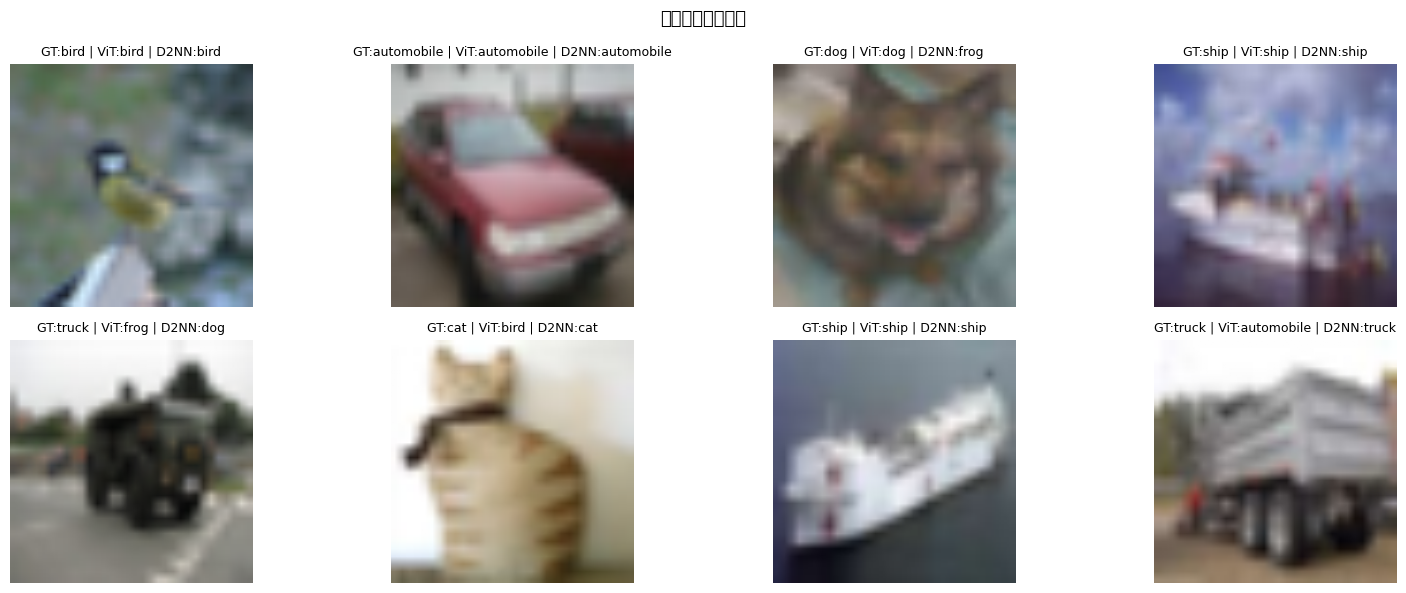

✅ 随机样例可视化完成


In [16]:
# 从测试集中随机抽一批，展示图像 + GT + 两模型预测
idxs = np.random.choice(len(test_ds), size=8, replace=False)

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(16, 6))
for i, idx in enumerate(idxs):
    img, label = test_ds[idx]
    x = img.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        vit_pred = vit_model(x).argmax(dim=1).item()
        d2nn_pred = d2nn_model(x).argmax(dim=1).item()

    ax = plt.subplot(2, 4, i + 1)
    vis = (img * 0.5 + 0.5).permute(1, 2, 0).numpy()
    vis = np.clip(vis, 0, 1)
    ax.imshow(vis)
    ax.set_title(
        f"GT:{classes[label]} | ViT:{classes[vit_pred]} | D2NN:{classes[d2nn_pred]}",
        fontsize=9
    )
    ax.axis("off")


plt.suptitle("测试样例预测对比", fontsize=13)
plt.tight_layout()
plt.show()
print("✅ 随机样例可视化完成")